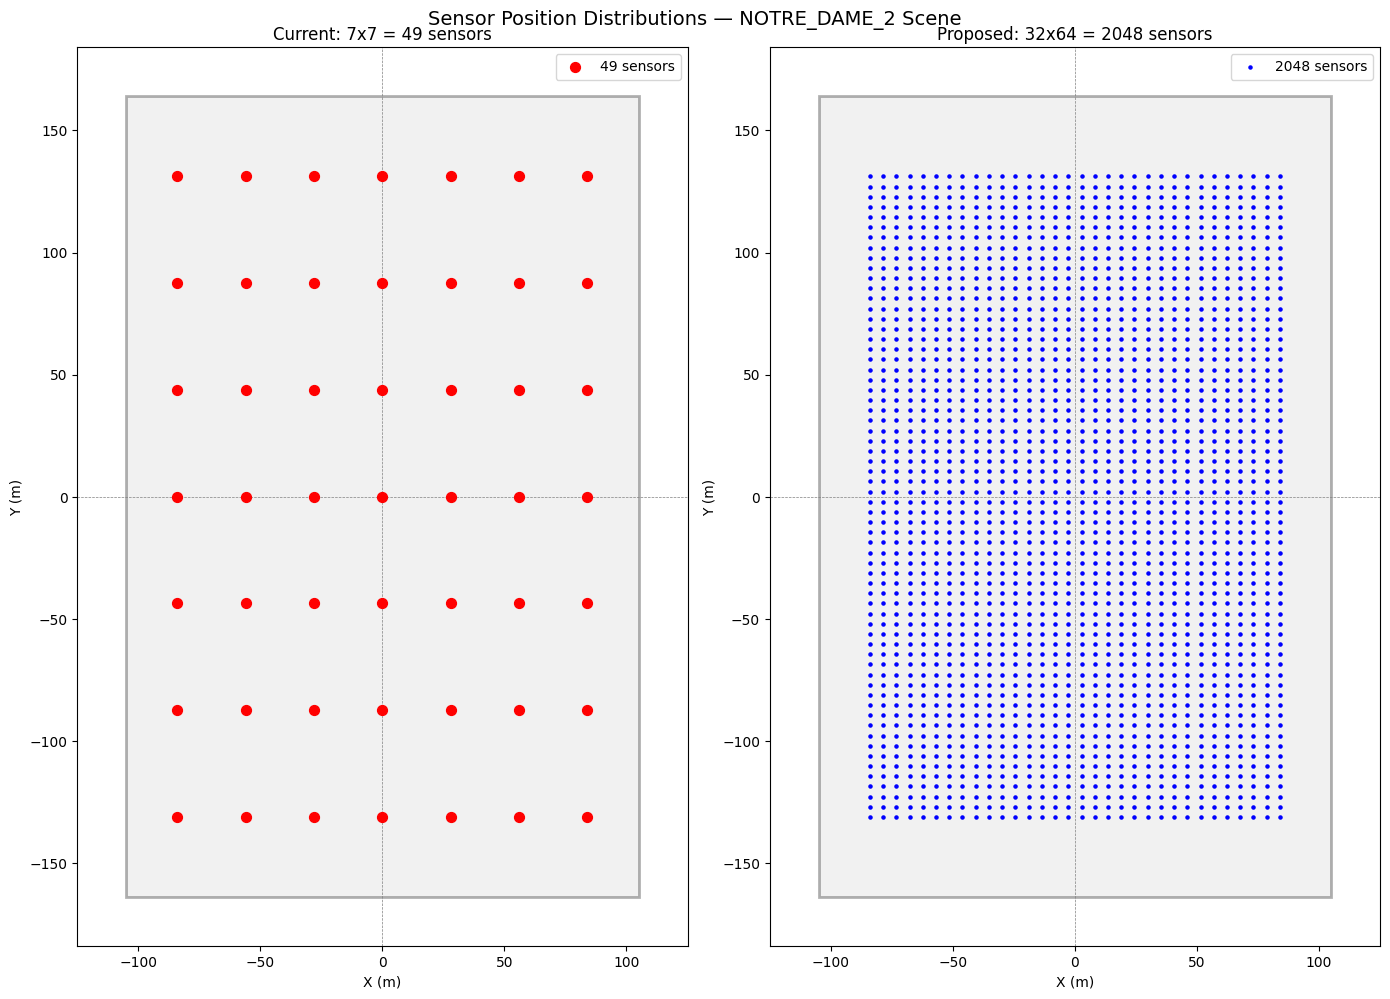

Saved sensor_positions_preview.png


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ── Constants (same as dataset_gen) ───────────────────────────────────────────
X_MIN, X_MAX = -105, 105
Y_MIN, Y_MAX = -164, 164

# Current 7x7 grid
N_SENSORS_X = 7
N_SENSORS_Y = 7

# Proposed 2048 grid (32x64 = 2048, matches quad aspect ratio)
N_SENSORS_X_NEW = 32
N_SENSORS_Y_NEW = 64

# ── Generate sensor positions ──────────────────────────────────────────────────
# Current
sensor_x_old = np.linspace(X_MIN * 0.8, X_MAX * 0.8, N_SENSORS_X)
sensor_y_old = np.linspace(Y_MIN * 0.8, Y_MAX * 0.8, N_SENSORS_Y)
SX, SY = np.meshgrid(sensor_x_old, sensor_y_old)
old_positions = np.stack([SX.flatten(), SY.flatten()], axis=1)

# New
sensor_x_new = np.linspace(X_MIN * 0.8, X_MAX * 0.8, N_SENSORS_X_NEW)
sensor_y_new = np.linspace(Y_MIN * 0.8, Y_MAX * 0.8, N_SENSORS_Y_NEW)
SX, SY = np.meshgrid(sensor_x_new, sensor_y_new)
new_positions = np.stack([SX.flatten(), SY.flatten()], axis=1)

# ── Plot side by side ──────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 10))

# Scene boundary box
def draw_scene(ax):
    rect = patches.Rectangle((X_MIN, Y_MIN), X_MAX-X_MIN, Y_MAX-Y_MIN,
                               linewidth=2, edgecolor='black', facecolor='lightgray', alpha=0.3)
    ax.add_patch(rect)
    ax.set_xlim(X_MIN - 20, X_MAX + 20)
    ax.set_ylim(Y_MIN - 20, Y_MAX + 20)
    ax.set_aspect('equal')
    ax.set_xlabel("X (m)")
    ax.set_ylabel("Y (m)")
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
    ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')

# Old grid
draw_scene(ax1)
ax1.scatter(old_positions[:, 0], old_positions[:, 1], 
            c='red', s=50, zorder=5, label=f'{len(old_positions)} sensors')
ax1.set_title(f"Current: {N_SENSORS_X}x{N_SENSORS_Y} = {len(old_positions)} sensors")
ax1.legend()

# New grid
draw_scene(ax2)
ax2.scatter(new_positions[:, 0], new_positions[:, 1],
            c='blue', s=5, zorder=5, label=f'{len(new_positions)} sensors')
ax2.set_title(f"Proposed: {N_SENSORS_X_NEW}x{N_SENSORS_Y_NEW} = {len(new_positions)} sensors")
ax2.legend()

plt.suptitle("Sensor Position Distributions — NOTRE_DAME_2 Scene", fontsize=14)
plt.tight_layout()
plt.savefig("sensor_positions_preview.png", dpi=100)
plt.show()
print("Saved sensor_positions_preview.png")